# 04_05 Flow Accumulation (D8 Drainage Model)

## 1. Introduction

Previous notebooks established three important concepts:

- Elevation describes the terrain surface.
- Flow strength describes how rapidly elevation changes.
- Flow direction describes the direction water would move.

The next question is:

> If water follows these flow directions, where does it eventually collect?

Flow accumulation attempts to answer this question.

It estimates how many upstream cells contribute water to each location.

Cells receiving water from many upstream locations develop high accumulation values and often correspond to:

- rivers
- streams
- drainage channels
- wetlands
- low valleys
- groundwater recharge zones

Cells with little contributing area generally occur on:

- ridges
- hills
- local high points
- drainage divides

This allows us to move from local terrain properties to large-scale watershed structure.

## 2. What is the D8 Model?

The D8 algorithm assumes that water leaving a cell flows toward the single neighboring cell with the steepest downhill slope.

Each cell has eight possible neighbors:

NW   N   NE
 W   X    E
SW   S   SE

Water is routed toward whichever neighboring cell produces the greatest decrease in elevation.

Although real water can split into multiple directions, the D8 method is:

- computationally efficient
- physically intuitive
- widely used in hydrology
- sufficient for regional watershed analysis

The result is a flow network that approximates drainage pathways across the terrain.

## 3. Mathematical Interpretation

Let:

$$
z_i
$$

represent the elevation of the current cell.

For each neighboring cell:

$$
z_j
$$

the local downhill slope is:

$$
s_{ij} =
\frac{z_i - z_j}{d_{ij}}
$$

where:

- $z_i$ = current elevation
- $z_j$ = neighboring elevation
- $d_{ij}$ = distance between cells

The D8 algorithm selects:

$$
\max(s_{ij})
$$

meaning:

> Water flows toward the steepest descent.

Accumulation then counts how many upstream cells eventually flow into each location.

### 4. Flow Patterns

Flow direction fields can exhibit several recognizable patterns.

### Divergent Flow

Water spreads outward.

Examples:

- ridges
- hills
- local high points

### Parallel Flow

Water moves in roughly the same direction.

Examples:

- broad slopes
- valley sides

### Convergent Flow

Flow vectors point toward a common location.

Examples:

- valleys
- streams
- drainage channels

### Circular or Closed Flow

Flow directions circulate or converge inward.

These patterns may indicate:

- depressions
- wetlands
- recharge zones
- infiltration areas

The Waterloo Moraine exhibits several regions of convergent and inward-directed flow, suggesting that portions of the moraine act as groundwater recharge zones rather than simple runoff-producing slopes.

## 5. Why Accumulation Matters

Flow accumulation is one of the most important terrain-derived variables.

It can help identify:

- stream networks
- drainage basins
- wetland locations
- recharge zones
- flood-prone areas
- river corridors

In Waterloo Region, accumulation patterns are expected to highlight:

- the Grand River valley
- major tributaries
- lowland drainage pathways
- convergent regions within the Waterloo Moraine

## 6. Imports

In [8]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import generic_filter

## 7. Load Data

In [23]:
with rasterio.open("../../data/Elevation/clipped_dem.tif") as src:
    dem = src.read(1)
    bounds = src.bounds
    nodata = src.nodata

dem = np.where(dem == nodata, np.nan, dem)

## 8. Compute Cell Spacing

In [24]:
rows, cols = dem.shape

mean_lat = (bounds.top + bounds.bottom) / 2

lat_m = 111320
lon_m = 111320 * np.cos(np.radians(mean_lat))

dx_spacing = lon_m * (bounds.right - bounds.left) / cols
dy_spacing = lat_m * (bounds.top - bounds.bottom) / rows

## 9. D8 Neighbor Directions

The D8 algorithm considers eight neighboring cells.

Diagonal neighbors are farther away and therefore use a larger distance.

These distances are used to compute downhill slope.

In [25]:
neighbor_offsets = [
    (-1, -1),
    (-1,  0),
    (-1,  1),
    ( 0, -1),
    ( 0,  1),
    ( 1, -1),
    ( 1,  0),
    ( 1,  1)
]

neighbor_distances = [
    np.sqrt(dx_spacing**2 + dy_spacing**2),
    dy_spacing,
    np.sqrt(dx_spacing**2 + dy_spacing**2),
    dx_spacing,
    dx_spacing,
    np.sqrt(dx_spacing**2 + dy_spacing**2),
    dy_spacing,
    np.sqrt(dx_spacing**2 + dy_spacing**2)
]

## 10. Compute Flow Directions

Each cell routes water toward the steepest downhill neighbor.

In [26]:
flow_to = np.full((rows, cols, 2), -1, dtype=int)

for r in range(1, rows - 1):
    for c in range(1, cols - 1):

        if np.isnan(dem[r, c]):
            continue

        current = dem[r, c]

        best_slope = 0
        best_cell = None

        for (dr, dc), dist in zip(
            neighbor_offsets,
            neighbor_distances
        ):

            rr = r + dr
            cc = c + dc

            if np.isnan(dem[rr, cc]):
                continue

            slope = (current - dem[rr, cc]) / dist

            if slope > best_slope:
                best_slope = slope
                best_cell = (rr, cc)

        if best_cell is not None:
            flow_to[r, c] = best_cell

## 11. Compute Flow Accumulation

Each cell contributes one unit of water.

Water is then routed downstream through the flow network.

Cells receiving many upstream contributions develop large accumulation values.

In [27]:
accumulation = np.ones((rows, cols), dtype=float)

order = np.argsort(-np.nan_to_num(dem, nan=-9999).ravel())

for idx in order:

    r, c = np.unravel_index(idx, dem.shape)

    rr, cc = flow_to[r, c]

    if rr >= 0:
        accumulation[rr, cc] += accumulation[r, c]

## 12. Visualize Flow Accumulation

Accumulation values can span several orders of magnitude.

A logarithmic color scale allows both small and large drainage pathways to be visible.

Without the log scaling we would only see the most prominent drainage areas. However the next notebook focuses specifically on extracting drainage networks, so I will leave that for the next notebook. 

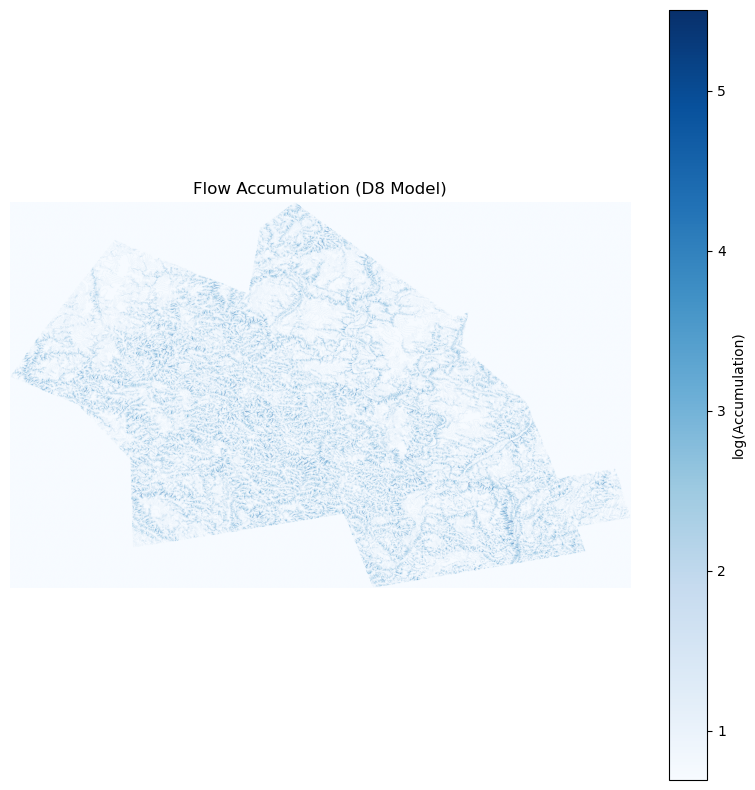

In [32]:
plt.figure(figsize=(10, 10))

masked_accumulation = np.ma.masked_invalid(accumulation)

plt.imshow(
    np.log1p(masked_accumulation),
    cmap="Blues",
    origin="upper"
)

plt.title("Flow Accumulation (D8 Model)")
plt.axis("off")

cbar = plt.colorbar()
cbar.set_label("log(Accumulation)")

plt.show()

## 13. Interpretation

High accumulation values indicate locations where water from many upstream cells converges.

Low accumulation values occur where water leaves the landscape.

General interpretation:

- low accumulation → ridges and divides
- moderate accumulation → hillslopes
- high accumulation → valleys and channels

In Waterloo Region we expect high accumulation values along:

- the Grand River valley
- tributary systems
- lowland drainage corridors

Regions of inward-directed flow on the Waterloo Moraine may also develop localized accumulation zones.

These areas may represent:

- infiltration regions
- recharge zones
- wetlands
- groundwater storage areas

Thus accumulation allows us to move from:

- local slope
- local flow direction

to:

- regional drainage structure
- watershed organization
- hydrological connectivity

## 14. Conclusion

Flow accumulation transforms local terrain gradients into a regional drainage network by highlighting accumulation zones.

Previous notebooks answered:

- How high is the terrain?
- How steep is the terrain?
- Which direction does water move?

This notebook answers:

> Where does water collect?

The resulting accumulation field provides the foundation for:

- stream extraction
- watershed delineation
- drainage analysis
- flood studies
- groundwater investigations

It represents one of the most important terrain-derived products in hydrology.